# Student Performance Analysis

## Objective
#### The objective of this project is to analyze student academic performance and understand how factors such as demographics, family background,study habits, absences, health, and previous academic performance are related to students' final grades.

## Data Dictionary

| Feature | Description |
|---|---|
| school | Student's school |
| sex | Student's sex |
| age | Student's age |
| address | Type of home address (urban/rural) |
| famsize | Family size |
| Pstatus | Parent's cohabitation status |
| Medu | Mother's education level |
| Fedu | Father's education level |
| Mjob | Mother's job |
| Fjob | Father's job |
| guardian | Student's guardian |
| studytime | Weekly study time |
| failures | Number of previous class failures |
| schoolsup | Extra educational support |
| famsup | Family educational support |
| paid | Extra paid classes |
| activities | Participation in extracurricular activities |
| nursery | Attended nursery school |
| higher | Desire to pursue higher education |
| internet | Internet access at home |
| romantic | Romantic relationship |
| famrel | Quality of family relationships |
| freetime | Free time after school |
| goout | Going out with friends |
| health | Current health status |
| absences | Number of school absences |
| G1 | First-period grade |
| G2 | Second-period grade |
| G3 | Final grade |

## Import Libraries

In [80]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
data=pd.read_csv('student_data.csv')

# 1.UNDERSTANDING DATA

In [47]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

##### Insight : The dataset contains 395 students and 33 variables, with no missing values. It includes 16 numerical and 17 categorical features, covering students’ demographics, family background, study habits, social activities, health, absences, and academic performance.


In [49]:
data.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [50]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


##### Insight: The descriptive statistics show that students have an average age of 16.7 years, with most students between 16 and 18 years. The average final grade (G3) is 10.42, with scores ranging from 0 to 20. Parents’ education levels average around 2–3, indicating moderate educational backgrounds overall.


In [81]:
data.shape


(395, 33)

In [82]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

# 2.DATA CLEANING

In [83]:
data.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

##### Insight: The dataset contains no missing values in any of the 33 columns, so the data is complete and does not require missing-value treatment before analysis.

In [84]:
data.duplicated().sum()

np.int64(0)

##### Insight: The dataset contains no duplicate records, indicating that each student entry is unique and the dataset does not require duplicate-row removal.

In [85]:
data[['G1','G2','G3']].describe()

,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


##### Insight: The average grades increase slightly from G1 (10.91) to G2 (10.71) and G3 (10.42). The grades range from 0 to 19/20, showing considerable variation in student performance across the three periods.

In [86]:
data['G3'].value_counts().sort_index()

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

##### Insight: The final grade (G3) is most commonly 10, followed by 11 and 8. A considerable number of students scored 0, while very few students achieved scores of 19 or 20, indicating that extremely high scores are uncommon in the dataset.

In [87]:
data['G1'].value_counts().sort_index()

G1
3      1
4      1
5      7
6     24
7     37
8     41
9     31
10    51
11    39
12    35
13    33
14    30
15    24
16    22
17     8
18     8
19     3
Name: count, dtype: int64

##### Insight: The distribution of G1 (first-period grade) is concentrated around 10–12, with 10 being the most common score. Very low and very high scores occur less frequently, indicating that most students achieved moderate performance in the first period.

In [88]:
data['G2'].value_counts().sort_index()

G2
0     13
4      1
5     15
6     14
7     21
8     32
9     50
10    46
11    35
12    41
13    37
14    23
15    34
16    13
17     5
18    12
19     3
Name: count, dtype: int64

##### Insight: The distribution of G2 (second-period grade) is concentrated around 10–11, with 10 being the most common score. Most students show moderate academic performance, while very low and very high scores are less frequent.

# ** EDA

# 3. Univariate Analysis

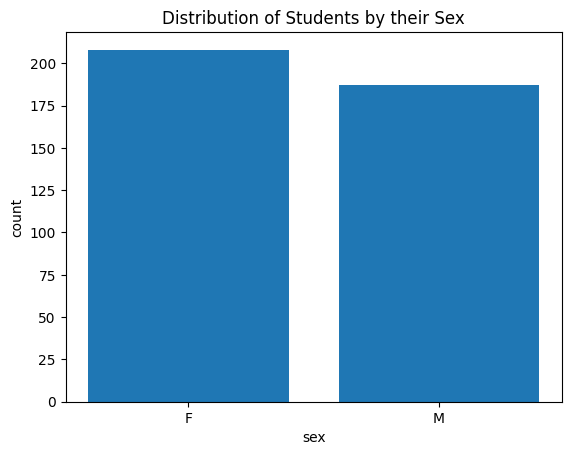

In [89]:
counts=data['sex'].value_counts()
plt.bar(counts.index,counts.values)
plt.title('Distribution of Students by their Sex')
plt.xlabel('sex')
plt.ylabel('count')
plt.show()

##### Insight: The dataset contains more female students than male students, indicating that female students make up the larger share of the sample.

<Axes: ylabel='age'>

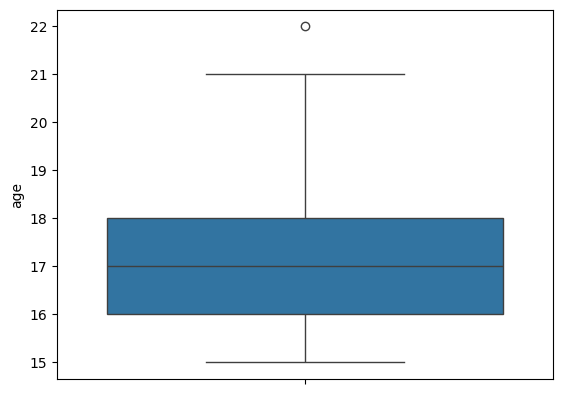

In [90]:
sns.boxplot(data['age'])

##### Insight: The boxplot shows that students’ ages are mostly concentrated between 15 and 18 years, with a few older students appearing as outliers.

Text(0, 0.5, 'Number of Students')

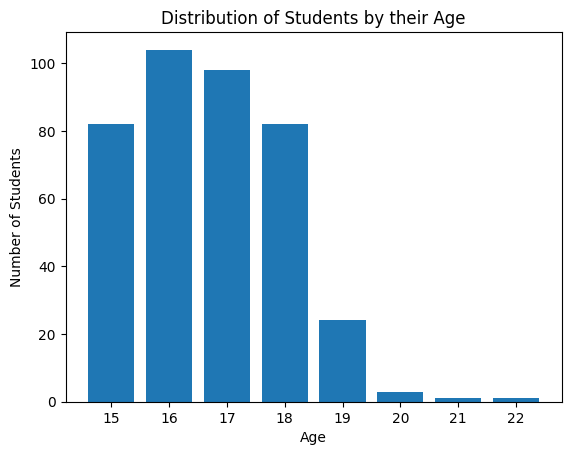

In [91]:
count=data['age'].value_counts()
plt.bar(count.index,count.values)
plt.title('Distribution of Students by their Age')
plt.xlabel('Age')
plt.ylabel('Number of Students')

Text(0, 0.5, 'Number Of Students')

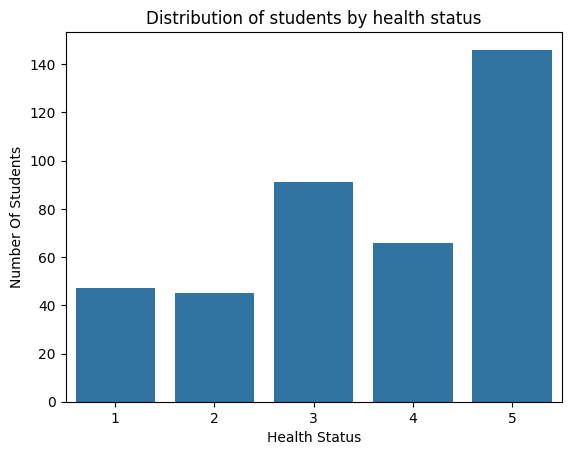

In [92]:
sns.countplot(data=data,x='health')
plt.title('Distribution of students by health status')
plt.xlabel('Health Status')
plt.ylabel('Number Of Students')

##### Insight: Most students report good to very good health (health levels 4 and 5), while relatively few students have poor health (levels 1 and 2).

Text(0, 0.5, 'Number Of Students')

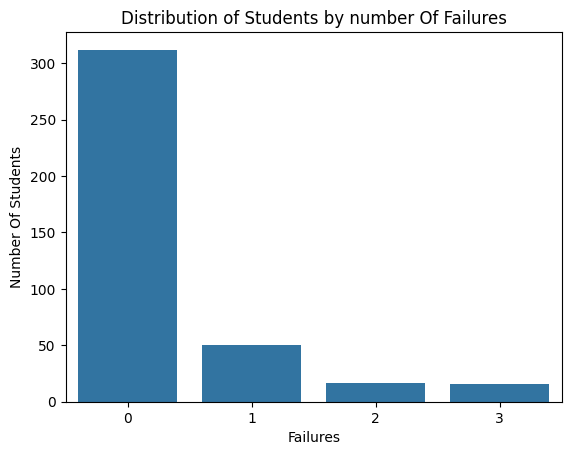

In [93]:
sns.countplot(data=data,x='failures')
plt.title('Distribution of Students by number Of Failures')
plt.xlabel('Failures')
plt.ylabel('Number Of Students')

##### Insight: Most students (312 out of 395) have no previous failures, while only a small proportion have experienced one or more failures. This indicates that previous academic failures are relatively uncommon in the dataset.

Text(0, 0.5, 'Number Of Students')

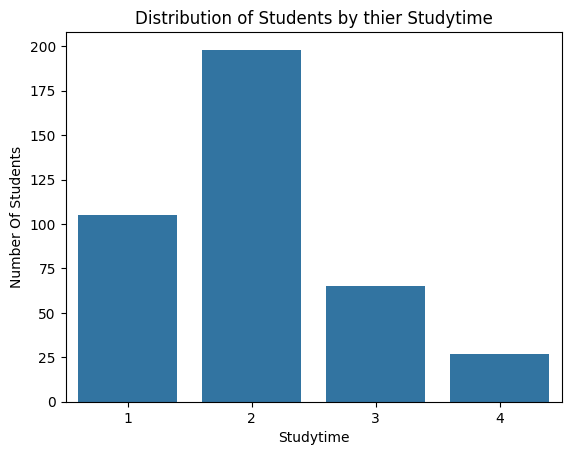

In [94]:
sns.countplot(data=data,x='studytime')
plt.title('Distribution of Students by thier Studytime')
plt.xlabel('Studytime')
plt.ylabel('Number Of Students')

##### Insight: Most students spend 2–5 hours per week studying, while relatively few students study for more than 5 hours per week. This suggests that moderate study time is most common in the dataset.

Text(0, 0.5, 'Number Of Students')

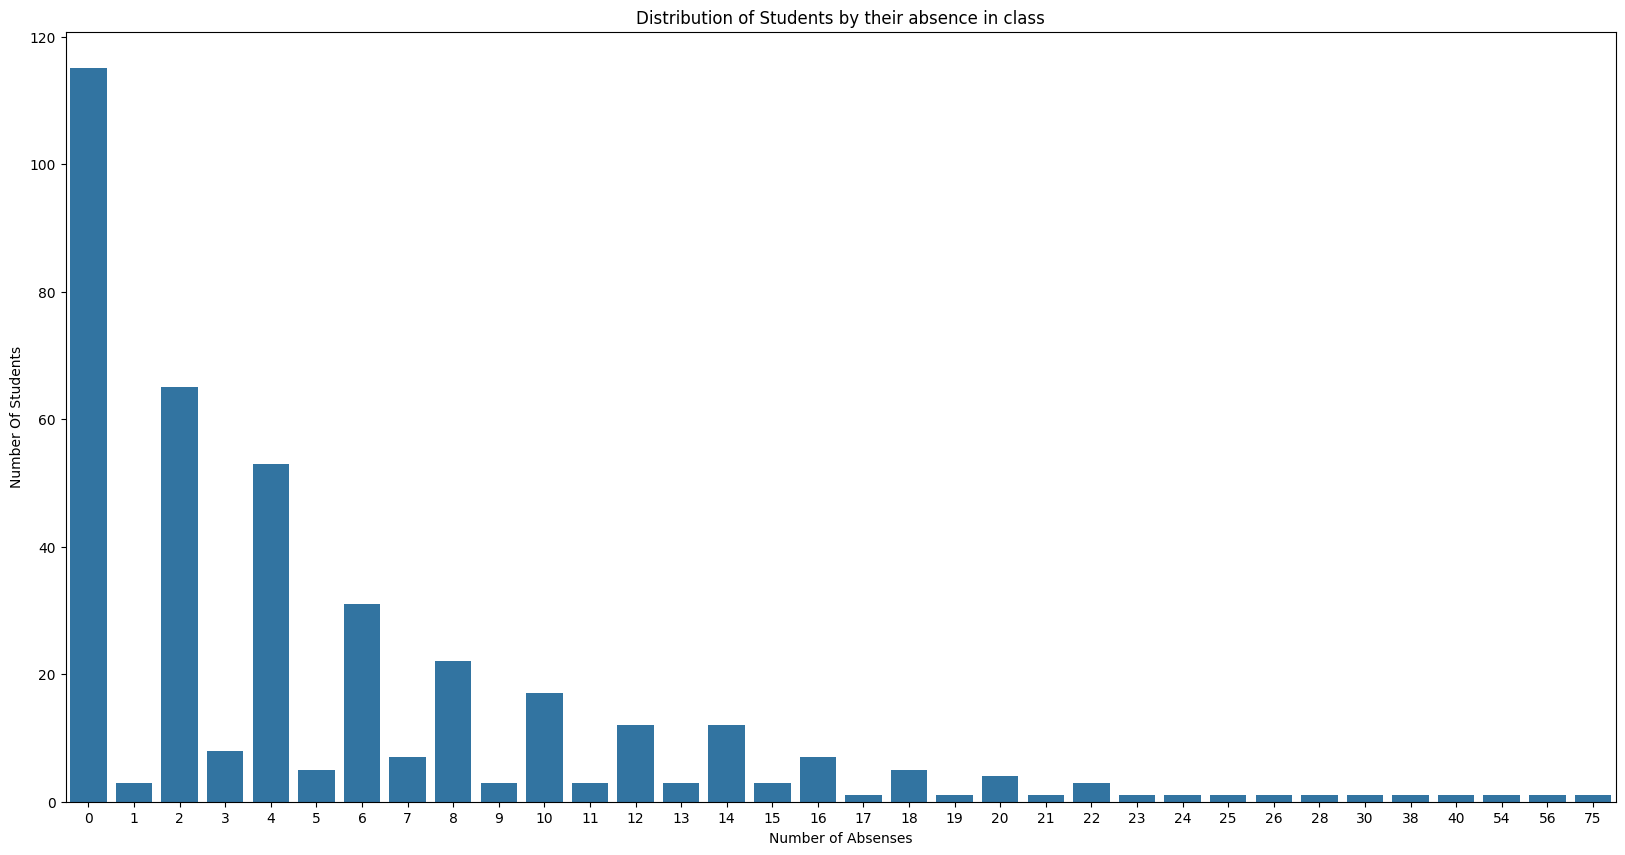

In [95]:
plt.figure(figsize=(20,10))
sns.countplot(data=data,x='absences')
plt.title('Distribution of Students by their absence in class')
plt.xlabel('Number of Absenses')
plt.ylabel('Number Of Students')

##### Insight: Most students have low absenteeism, with 115 students having no absences. The median number of absences is 4, while a small number of students have very high absences, with the maximum reaching 75.

Text(0, 0.5, 'Number Of Students')

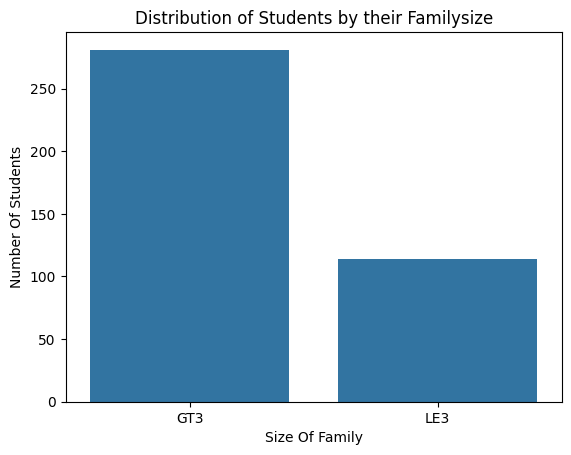

In [96]:
sns.countplot(data=data,x='famsize')
plt.title('Distribution of Students by their Familysize')
plt.xlabel('Size Of Family')
plt.ylabel('Number Of Students')

##### Insight: Most students belong to small families (LE3: ≤3 members), while a smaller proportion belong to larger families (GT3: >3 members).

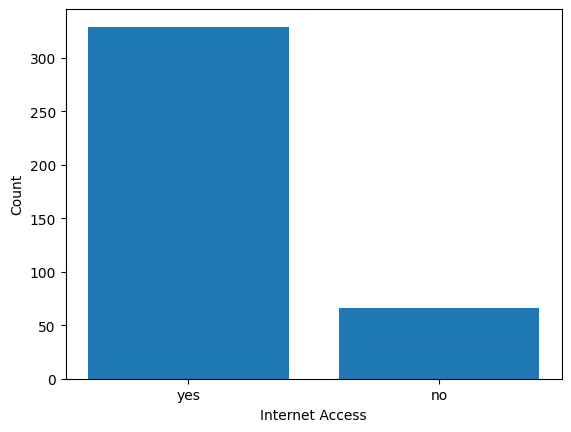

In [97]:
counts=data['internet'].value_counts()
plt.bar(counts.index,counts.values)
plt.xlabel('Internet Access')
plt.ylabel('Count')
plt.show()

##### Insight: The majority of students have internet access at home, while only a small proportion do not. This indicates that internet access is widely available among the students in the dataset.


# 4. Bivariate Analysis

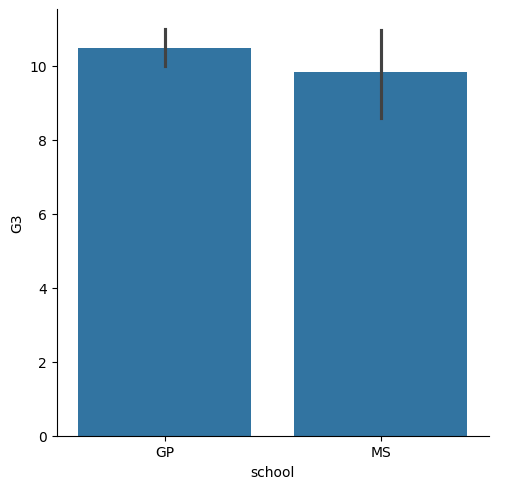

In [98]:
sns.catplot(x='school',y='G3',kind='bar',data=data)

##### Insight: Students from Gabriel Pereira (GP) school have a slightly higher average final grade (G3) than students from Mousinho da Silveira (MS) school, indicating a small difference in academic performance between the two schools.

<Axes: xlabel='sex', ylabel='G3'>

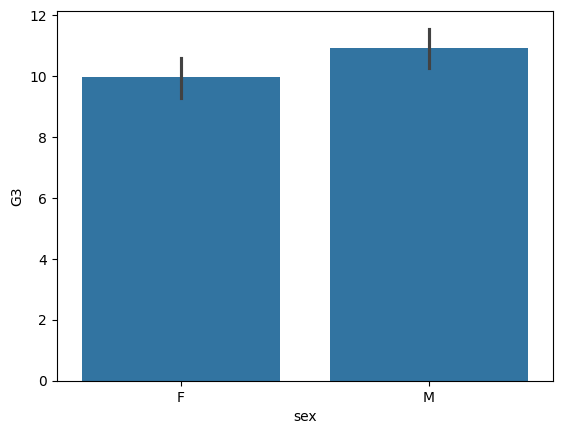

In [99]:
sns.barplot(data=data, x='sex', y='G3')

##### Insight: The average final grade (G3) is slightly higher for female students than male students, indicating a small difference in average academic performance between the two groups.

<Axes: xlabel='internet', ylabel='G3'>

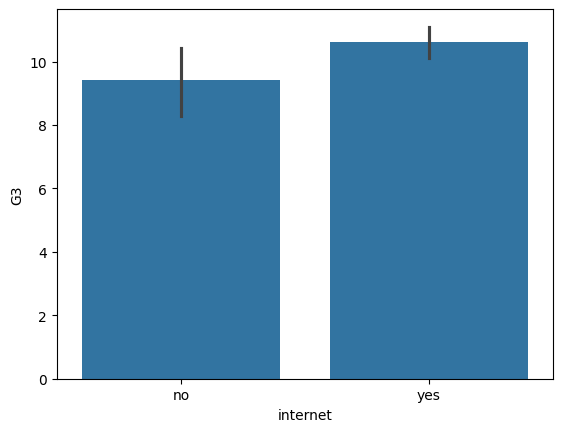

In [100]:
sns.barplot(data=data, x='internet', y='G3')

##### Insight: Students with internet access at home have a higher average final grade (G3 ≈ 10.62) compared with students without internet access (G3 ≈ 9.41). This suggests that access to the internet may be associated with better academic performance.

<Axes: xlabel='failures', ylabel='G3'>

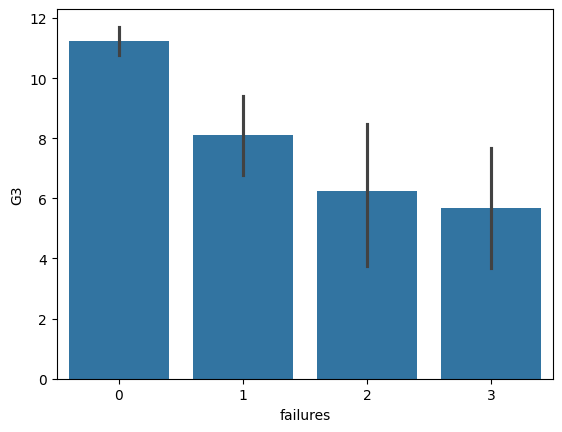

In [101]:
sns.barplot(data=data, x='failures', y='G3')

##### Insight: Students with no previous failures have the highest average final grade (G3). As the number of previous failures increases, the average final grade generally decreases, indicating a negative relationship between previous failures and academic performance.

<Axes: xlabel='G3', ylabel='absences'>

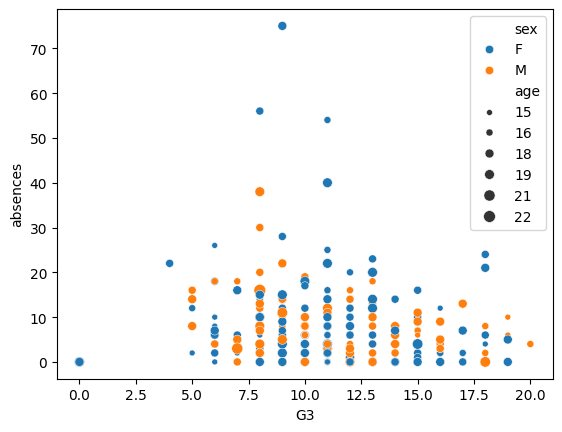

In [102]:
sns.scatterplot(data=data,x='G3',y='absences',hue='sex',size='age')

##### Insight: The scatter plot shows no strong relationship between absences and final grade (G3). Students with both low and high grades can have varying numbers of absences, although students with very high absence counts generally tend to have lower or moderate final grades.

In [103]:
Grades=data[['G1','G2','G3']]

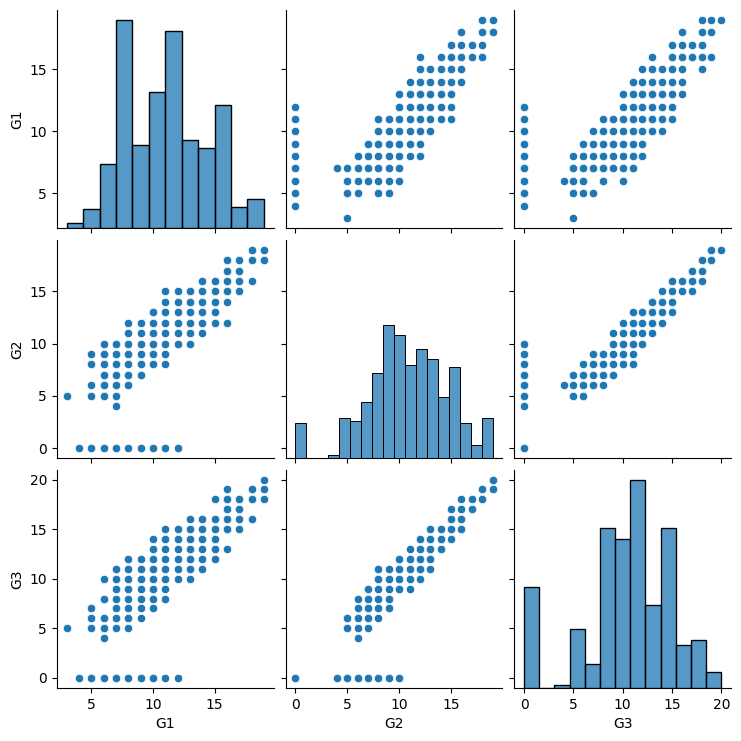

In [104]:
sns.pairplot(Grades)

##### Insight: The pairplot shows a strong positive relationship between G1, G2, and G3. Students who perform well in one grading period generally tend to perform well in the others, indicating that academic performance is relatively consistent across the three periods.

<Axes: xlabel='guardian', ylabel='G3'>

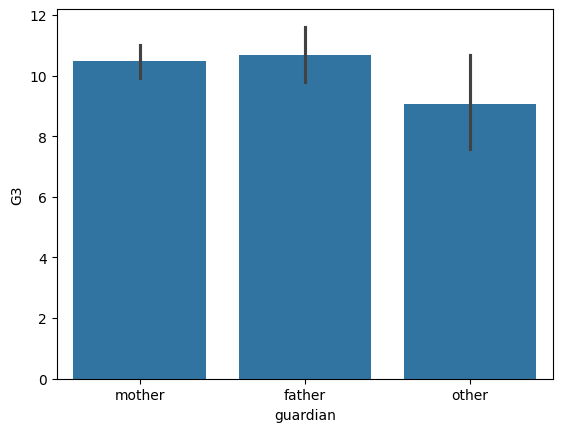

In [105]:
sns.barplot(data=data,x='guardian',y='G3')

##### Insight: Students with mother as their guardian have the highest average final grade (G3), followed by those with father as their guardian. Students with other guardians have the lowest average G3.

Text(0.5, 1.0, 'Analysis of Grades W.R.T Health')

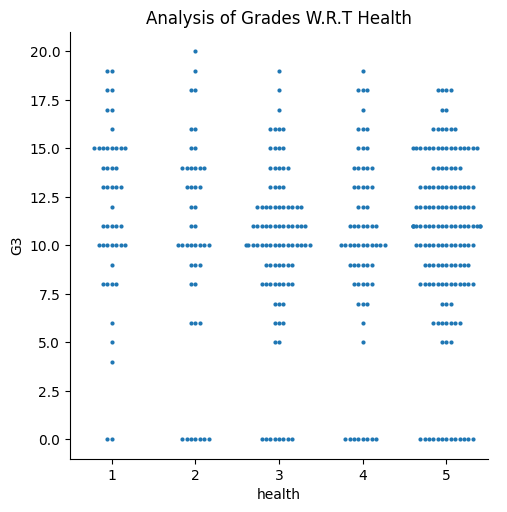

In [106]:
sns.catplot(x='health',y='G3',kind='swarm',size=3,data=data)
plt.title('Analysis of Grades W.R.T Health')

##### Insight: Students across all health levels show a wide range of final grades. However, better health does not show a clear or strong relationship with higher G3 scores, suggesting that health status alone is not a major predictor of final academic performance.

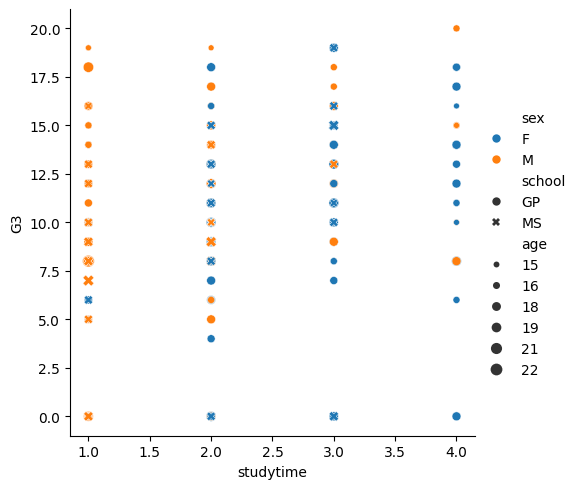

In [107]:
sns.relplot(x='studytime',y='G3',hue='sex',style='school',kind='scatter',size='age',data=data)

##### Insight: Students with moderate study time (levels 2–3) generally show a wide range of final grades, while students with higher study time (levels 4) do not consistently achieve higher grades. This suggests that study time alone does not strongly determine final academic performance.

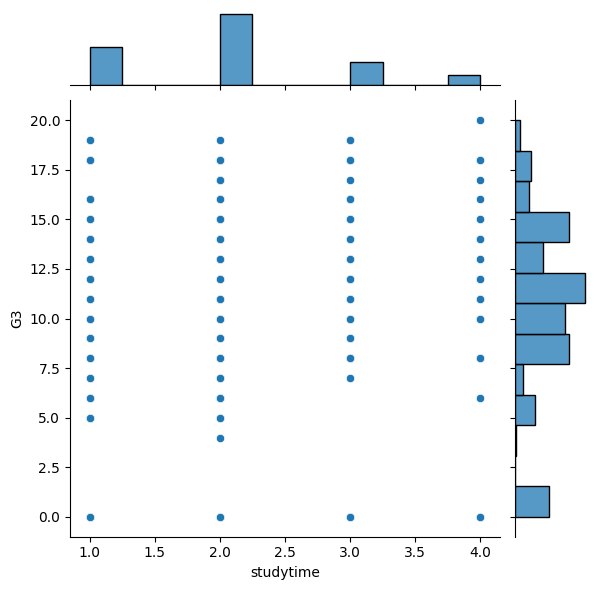

In [108]:
sns.jointplot(x='studytime',y='G3',data=data)

# 5. Correlation with Heatmap

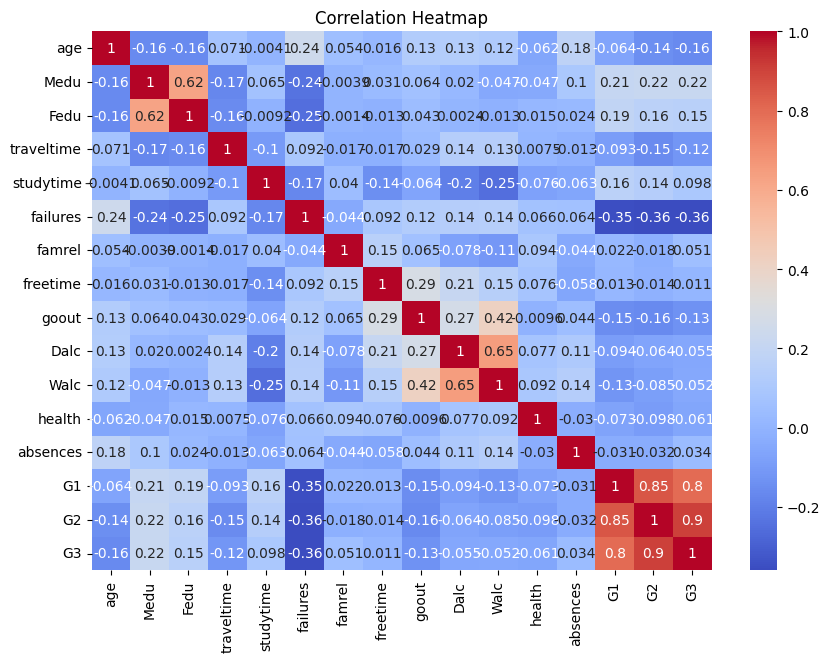

In [109]:
plt.figure(figsize=(10, 7))

sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

##### Insight: The correlation heatmap shows that G1, G2, and G3 have strong positive correlations, indicating that students who perform well in one period tend to perform well in the others. Failures and absences show negative correlations with G3, suggesting that students with more failures or absences generally tend to have lower final grades.

## Key Findings

- G1, G2, and G3 show a strong positive relationship, indicating that
  previous academic performance is strongly associated with final performance.
- Students with more previous failures generally tend to have lower final grades.
- Absences show a negative relationship with final grades, although the relationship
  is not very strong.
- Most students have moderate study time, but higher study time does not
  necessarily result in higher final grades.
- Internet access is available to the majority of students.
- GP students have a slightly higher average final grade than MS students.
- Most students report good to very good health, but health status alone
  does not appear to strongly determine final grades.